# Notebook 03 — Regression Diagnostic

**Project:** SNAP Participation and Food Access  
**Data:** USDA Food Access Research Atlas (2019)  
**Research question:** Are census tracts with higher SNAP participation more likely to experience low supermarket access, and does this relationship differ between urban and rural areas?

In [6]:
import numpy as np
import scipy
import pandas as pd

import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Diagnostics

The data and the first 5 rows of the data.

In [7]:
path = 'food_access_modeling.csv'
df_model = pd.read_csv(path)
df_model.head(5)

,CensusTract,State,County,Urban,urban_label,Pop2010,OHU2010,PovertyRate,MedianFamilyIncome,log_median_family_income,...,log_response,pct_children,pct_seniors,pct_white,pct_black,pct_asian,pct_hispanic,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle
0,1001020100,Alabama,Autauga County,1,Urban,1912,693,11.336453,81250.0,11.305286,...,3.223299,26.516736,11.558577,84.832636,11.349372,0.732218,2.301255,0,0,0
1,1001020200,Alabama,Autauga County,1,Urban,2170,743,17.876788,49000.0,10.799576,...,3.361387,27.926267,9.861751,40.921659,56.082949,0.230415,3.456221,1,1,0
2,1001020300,Alabama,Autauga County,1,Urban,3373,1256,15.046030,62609.0,11.044664,...,2.719919,26.504595,13.015120,76.371183,19.181737,0.504002,2.579306,0,0,0
3,1001020400,Alabama,Autauga County,1,Urban,4386,1722,2.845210,70607.0,11.164885,...,2.177617,23.141815,20.611035,93.160055,4.400365,0.410397,1.937984,0,0,0
4,1001020500,Alabama,Autauga County,1,Urban,10766,4082,15.150891,96334.0,11.475577,...,1.863599,29.370240,10.458852,80.494148,13.347576,2.749396,3.297418,0,0,0


---
### Fitting the model to a full model

In [8]:
response = 'pct_low_income_low_access'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_model).fit()

full_model.summary()

full_formula:  pct_low_income_low_access ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     pct_low_income_low_access   R-squared:                       0.195
Model:                                   OLS   Adj. R-squared:                  0.195
Method:                        Least Squares   F-statistic:                     1022.
Date:                       Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                               22:47:07   Log-Likelihood:            -1.6394e+05
No. Observations:                      42156   AIC:                         3.279e+05
Df Residuals:                          42145   BIC:                         3.280e+05
Df Model:                                 10                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   80.5962      2.954     27.287      0.000      74.807      86.385
pct_snap                     0.0279      0.011      2.486      0.013       0.006       0.050
PovertyRate                  0.2540      0.010     24.435      0.000       0.234       0.274
log_median_family_income    -7.3335      0.254    -28.852      0.000      -7.832      -6.835
pct_no_vehicle              -0.2196      0.012    -18.094      0.000      -0.243      -0.196
Urban                        5.2818      0.168     31.496      0.000       4.953       5.610
pct_children                 0.1925      0.013     14.610      0.000       0.167       0.218
pct_seniors                  0.0727      0.010      7.452      0.000       0.054       0.092
pct_black                    0.0308      0.003      8.794      0.000       0.024       0.038
pct_hispanic                -0.0493      0.004    -12.900      0.000      -0.057      -0.042
pct_asian                   -0.0982      0.010    -10.125      0.000      -0.117      -0.079
==============================================================================
Omnibus:                     9774.425   Durbin-Watson:                   1.636
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24609.872
Skew:                           1.272   Prob(JB):                         0.00
Kurtosis:                       5.746   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model Diagnosis 

The 5 different things we need to check:
* Independence: $\epsilon_1 ... \epsilon_n$ are independent
* Identical / homoscedasticity: The errors have constant variance, i.e., $\epsilon_1 ... \epsilon_n$ are $N(0,r^2)$
* Normally distributed (Normality): $\epsilon_1 ... \epsilon_n$ are $\underset{=}{N}(0,r^2)$
* Linearity: The relationship between the independent variables and the response is linear $y_i = B_0 + B_1 x_i$
* Multicollinearity: The Case where two or more covariates are highly correlated. 

### Identical/homoscedasticity and Linearity

We check whether the error have constant variance for homoscedasticity. Additionally, we check if the residuals are randomly scattered around 0 then the assumption of linearity is satisfied.

Analysis: Both conditions are not reached as we can see linearity isn't true as it centers at a different value.

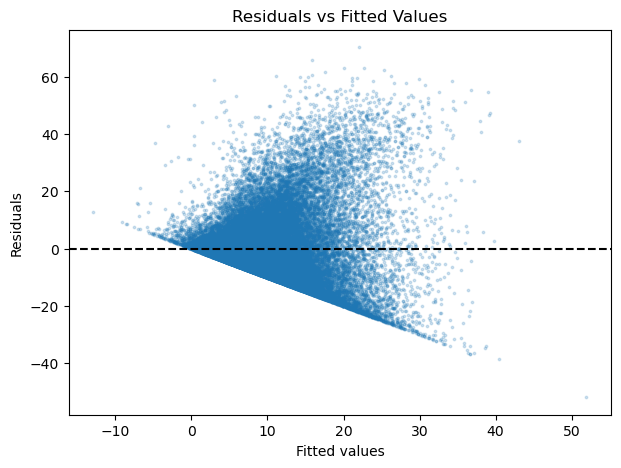

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(full_model.fittedvalues, full_model.resid, s=3, alpha=0.2)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

### Normally distributed

We check whether the model residuals look normal. 

Analysis: We can see that the plot is right skewed and the tail shift away from our expected linear condition. Thus, we don't reach the normality condition.

<Figure size 700x500 with 0 Axes>

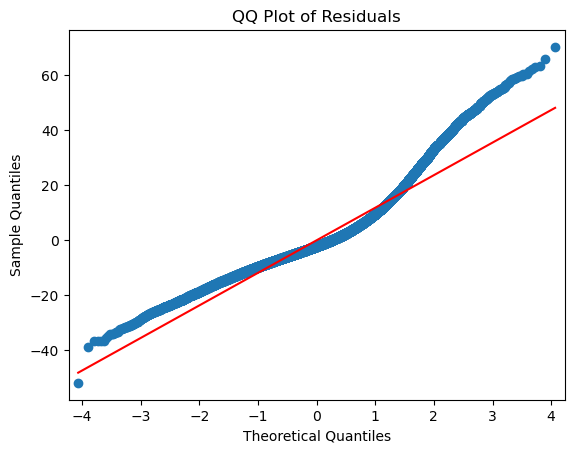

In [10]:
plt.figure(figsize=(7, 5))
sm.qqplot(full_model.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Multicollinearity

We can see that the covariates are nearly highly correlated. This is the case with pct_snap and pct_no_vehicles. Alongside pct_black with pct_snap, pct_no_vehicle,and poverty rate. The VIF aren't >5 but VIF for pct_snap is 4.477 so multicollinearity is still a risk.

['pct_snap', 'PovertyRate', 'log_median_family_income', 'pct_no_vehicle', 'Urban', 'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian']
VIF: pct_snap:  4.477
VIF: PovertyRate:  3.980
VIF: log_median_family_income:  4.015
VIF: pct_no_vehicle:  2.185
VIF: Urban:  1.219
VIF: pct_children:  1.852
VIF: pct_seniors:  1.694
VIF: pct_black:  1.583
VIF: pct_hispanic:  1.357
VIF: pct_asian:  1.226


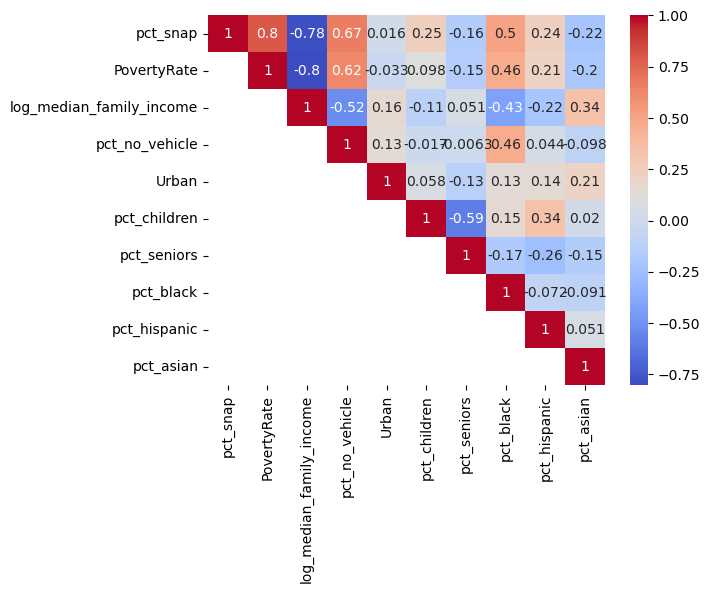

In [11]:
covariates_term = ['pct_snap','PovertyRate','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
print(covariates_term)
corr_table = df_model[covariates_term].corr() 
sns.heatmap(corr_table, annot=True, cmap='coolwarm', mask=np.tril(corr_table, k=-1))

exog = full_model.model.exog
names = full_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

---

### All 3 new models A,B,and C

Thus, we should changed our model such that model doesn't have issues with homoscedasticity, normality, linearity,and multicollinearity.

In [49]:
formula_A = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_A = smf.ols(formula_A, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_A.summary())

formula_B = (
    'log_response ~ pct_snap + PovertyRate'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_B = smf.ols(formula_B, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_B.summary())

formula_C = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_snap:Urban + pct_no_vehicle:Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_C = smf.ols(formula_C, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
#print(model_C.summary())
print('Model A VIF')
exog = model_A.model.exog
names = model_A.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')
print('Model B VIF')
exog = model_B.model.exog
names = model_B.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')
print('Model C VIF')
exog = model_C.model.exog
names = model_C.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

Model A VIF
VIF: pct_snap:  4.040
VIF: log_median_family_income:  3.173
VIF: pct_no_vehicle:  2.101
VIF: Urban:  1.219
VIF: pct_children:  1.791
VIF: pct_seniors:  1.636
VIF: pct_black:  1.577
VIF: pct_hispanic:  1.351
VIF: pct_asian:  1.220
Model B VIF
VIF: pct_snap:  3.858
VIF: PovertyRate:  3.145
VIF: pct_no_vehicle:  2.172
VIF: Urban:  1.155
VIF: pct_children:  1.847
VIF: pct_seniors:  1.681
VIF: pct_black:  1.565
VIF: pct_hispanic:  1.329
VIF: pct_asian:  1.152
Model C VIF
VIF: pct_snap:  18.251
VIF: log_median_family_income:  3.195
VIF: pct_no_vehicle:  23.227
VIF: Urban:  3.661
VIF: pct_snap:Urban:  21.757
VIF: pct_no_vehicle:Urban:  27.180
VIF: pct_children:  1.812
VIF: pct_seniors:  1.636
VIF: pct_black:  1.580
VIF: pct_hispanic:  1.354
VIF: pct_asian:  1.224


#### Checking all conditions for model A diagnosis 

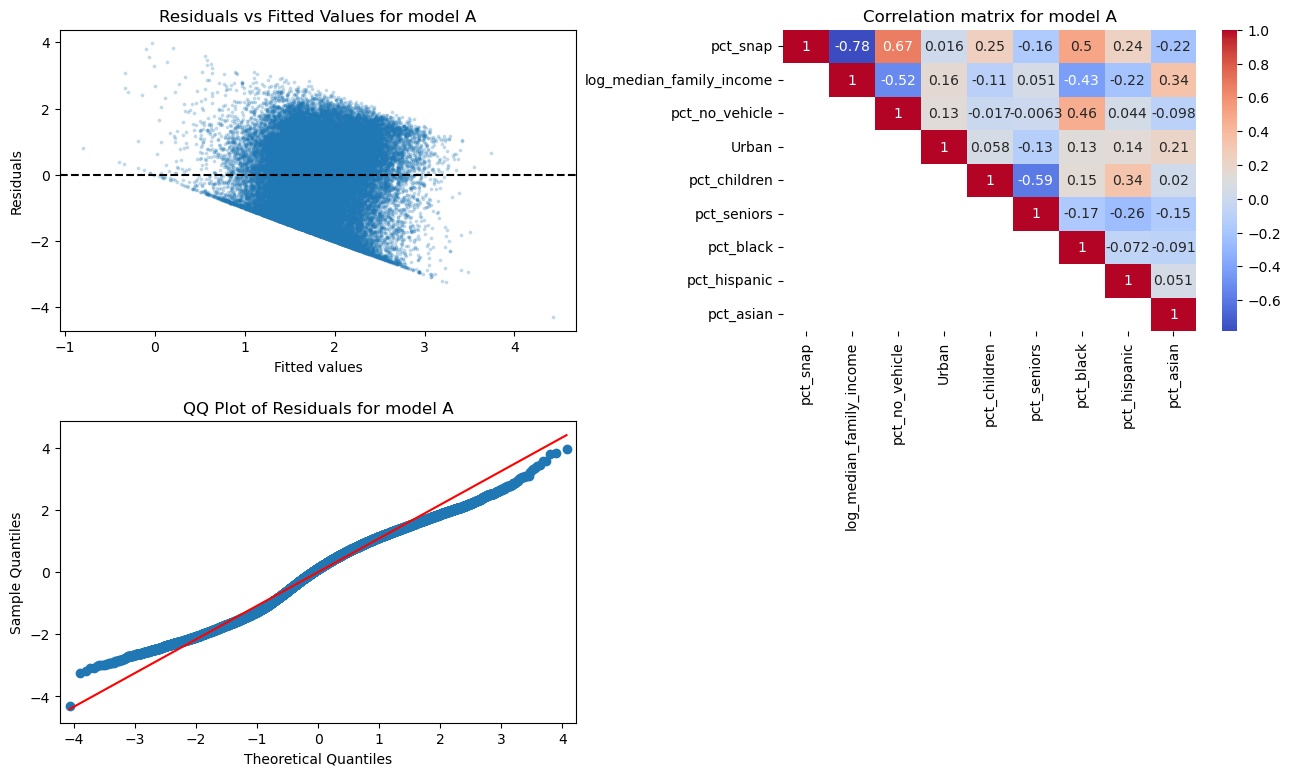

In [50]:
covariates_termA = ['pct_snap','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableA = df_model[covariates_termA].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_A.fittedvalues, model_A.resid, s=3, alpha=0.2)
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model A")
sm.qqplot(model_A.resid, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals for model A")
sns.heatmap(corr_tableA, annot=True, cmap='coolwarm', mask=np.tril(corr_tableA, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model A')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

---
#### Checking all conditions for model B diagnosis 

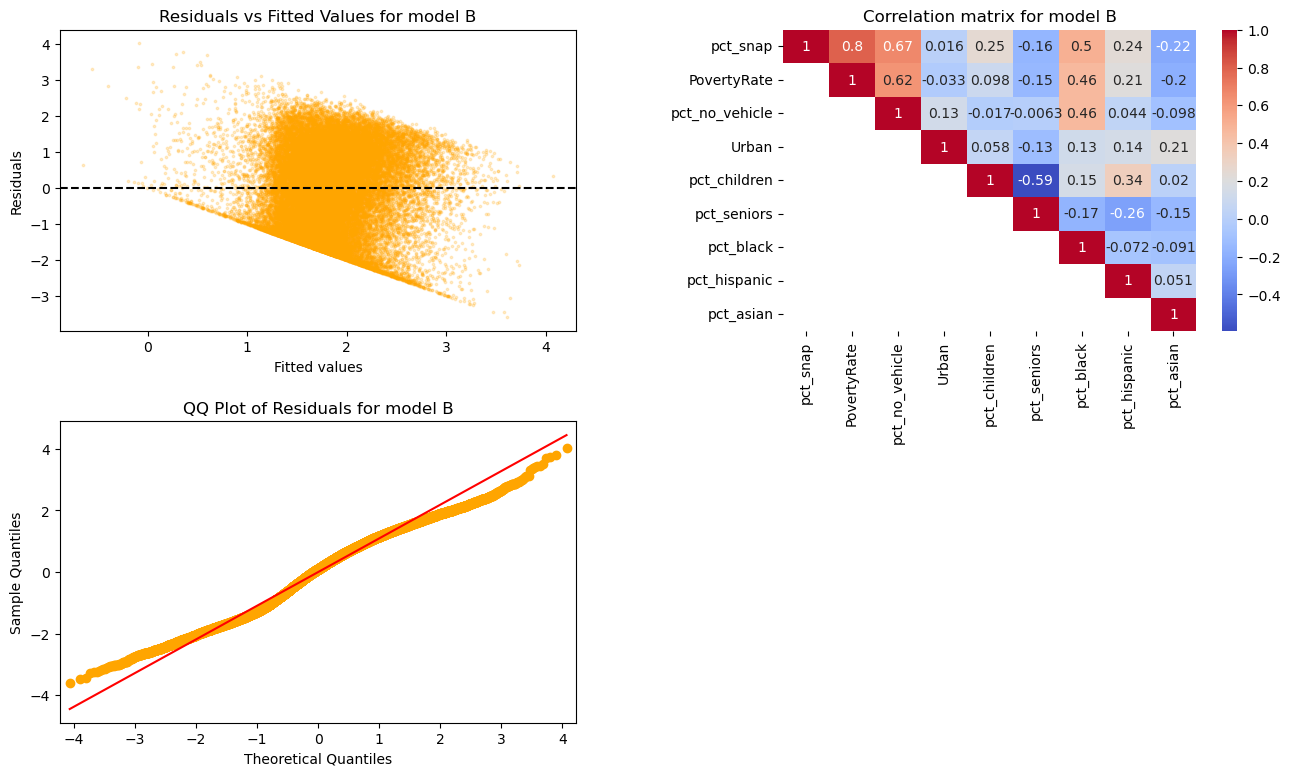

In [51]:
covariates_termB = ['pct_snap','PovertyRate','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableB = df_model[covariates_termB].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_B.fittedvalues, model_B.resid, s=3, alpha=0.2, c='orange')
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model B")
sm.qqplot(model_B.resid, line="s", ax=axes[1, 0],markerfacecolor='orange', markeredgecolor='orange')
axes[1, 0].set_title("QQ Plot of Residuals for model B")
sns.heatmap(corr_tableB, annot=True, cmap='coolwarm', mask=np.tril(corr_tableB, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model B')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

---
#### Checking all conditions for model C diagnosis 

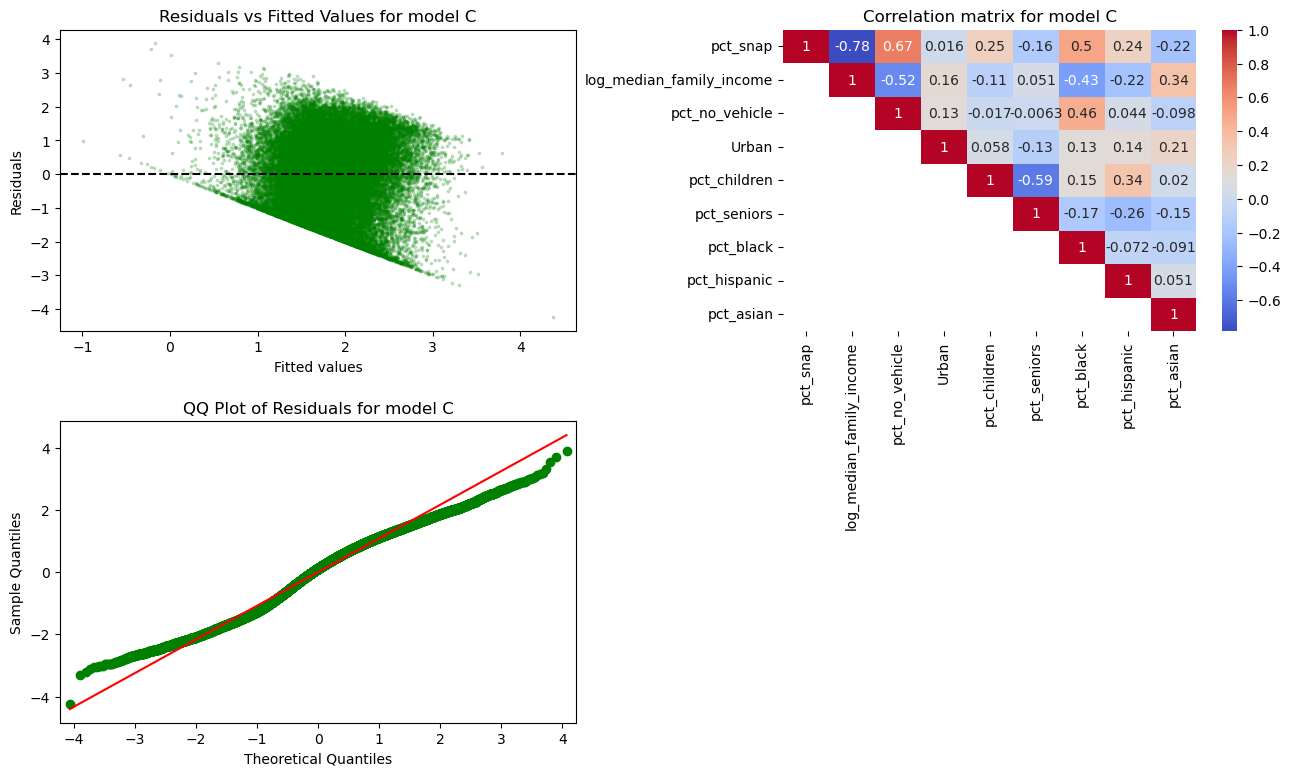

In [52]:
covariates_termC = ['pct_snap','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
corr_tableC = df_model[covariates_termC].corr() 

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].scatter(model_C.fittedvalues, model_C.resid, s=3, alpha=0.2, c='green')
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values for model C")
sm.qqplot(model_C.resid, line="s", ax=axes[1, 0],markerfacecolor='green', markeredgecolor='green')
axes[1, 0].set_title("QQ Plot of Residuals for model C")
sns.heatmap(corr_tableC, annot=True, cmap='coolwarm', mask=np.tril(corr_tableC, k=-1), ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix for model C')
plt.subplots_adjust(wspace=0.4,hspace=0.3) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

|Conditions|Model A analysis|Model B analysis|Model C analysis|
|:--:|:--:|:--:|:--:|
|Independence|$$\checkmark$$|$$\checkmark$$|$$\checkmark$$|
|Identical/homoscedasticity|Heteroscedasticity is noticable on Residual vs Fitted values.|Heteroscedasticity is noticable on Residual vs Fitted values.|Heteroscedasticity is noticable on Residual vs Fitted values.|
|Normality|We aren't able to satisfy the normality due to the heavy tails more noticable on the points below the line.| Similarly, we notice a heavier tail noticeable.|We notice a heavier tail compared to the model A and model B QQ-plots.|
|Linearity|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|We can see a noticable downtrend away from the center 0. Some skewed on tail ends but otherwise nearly satisfied.|
|Multicollinearity| Multicollinearity not pronounced via the VIF values. |Multicollinearity not pronounced via the VIF values. |Some severe level of multicollinearity compared to as Model A and Model B|

---